**Transfer learning with CIFAR 10 dataset**

In [5]:
#%pip install keras

In [6]:
#%pip install tensorflow

In [7]:
from __future__ import print_function

from time import time
import keras
from tensorflow.keras.datasets import mnist, cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras import backend as K

import matplotlib.pyplot as plt
import random

**Filters, Pool size, and Kernel size**

In [8]:
#number of convolutional filters to use
filters = 64
#size of pooling area for max pooling
pool_size = 2
#convolution kernel size
kernel_size = 3

Load and split the data between train and test sets

In [9]:
(x_cifar_train, y_cifar_train), (x_cifar_test, y_cifar_test) = cifar10.load_data()

In [10]:
y_cifar_train = y_cifar_train.reshape(50000,)
y_cifar_test = y_cifar_test.reshape(10000,)

Create 2 datasets, one with class labels below 5 and one with 5 and above

In [11]:
x_train_lt5 = x_cifar_train[y_cifar_train < 5]
y_train_lt5 = y_cifar_train[y_cifar_train < 5]
x_test_lt5 = x_cifar_test[y_cifar_test < 5]
y_test_lt5 = y_cifar_test[y_cifar_test < 5]

x_train_gte5 = x_cifar_train[y_cifar_train >= 5]
y_train_gte5 = y_cifar_train[y_cifar_train >= 5] - 5
x_test_gte5 = x_cifar_test[y_cifar_test >= 5]
y_test_gte5 = y_cifar_test[y_cifar_test >= 5] - 5

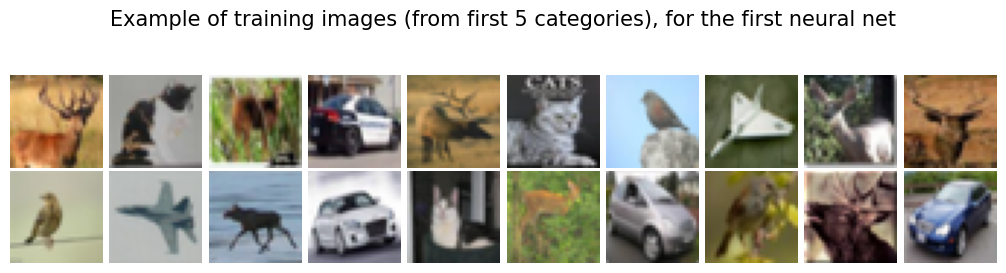

In [12]:
fig, ax = plt.subplots(2,10, figsize=(10,2.8))
fig.suptitle("Example of training images (from first 5 categories), for the first neural net\n", fontsize=15)
axes = ax.ravel()
for i in range (20):
    #pick a random number
    idx = random.randint(1,1000)
    axes[i].imshow(x_train_lt5[idx])
    axes[i].axis('off')
fig.tight_layout(pad=0.5)
plt.show()

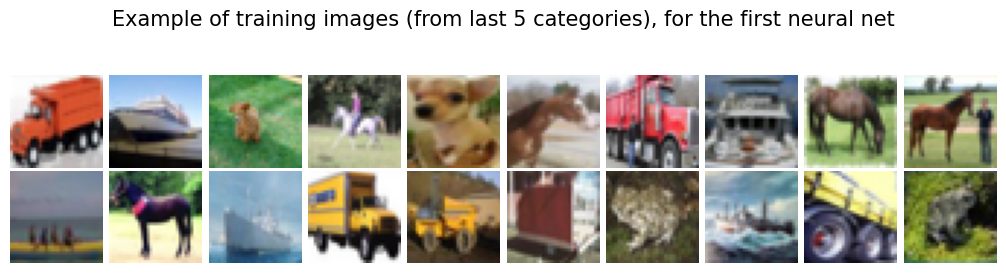

In [13]:
fig, ax = plt.subplots(2,10, figsize=(10,2.8))
fig.suptitle("Example of training images (from last 5 categories), for the first neural net\n", fontsize=15)
axes = ax.ravel()
for i in range (20):
    #pick a random number
    idx = random.randint(1,1000)
    axes[i].imshow(x_train_gte5[idx])
    axes[i].axis('off')
fig.tight_layout(pad=0.5)
plt.show()

set the number of classes and the input shape

In [14]:
num_classes = 5
input_shape = (32,32,3)

Define two groups of layers: feature (convolutions) and classification (dense)

In [15]:
feature_layers = [
    Conv2D(filters, kernel_size, 
           padding = 'valid', 
           input_shape = input_shape),
    Activation ('relu'),
    Conv2D(filters, kernel_size),
     Activation ('relu'),
    MaxPooling2D(pool_size = pool_size),
    Dropout(0.25),
    Flatten(),
]

C:\Users\oyelola Ibrahim\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
classification_layers = [
    Dense(128),
    Activation('relu'),
    Dropout(0.25),
    Dense(num_classes),
    Activation('softmax')
]

Create the complete model by stacking together feature_layers and classification_layers

In [17]:
model_1 = Sequential(feature_layers + classification_layers)

In [18]:
def train_model(model, train, test, num_classes):
    x_train = train[0].reshape((train[0].shape[0],) + input_shape)
    x_test = test[0].reshape((test[0].shape[0],) + input_shape)
    x_train = x_train.astype('float32')
    x_test = x_test.astype('float32')
    x_train /= 255
    x_test /= 255
    print('x_train shape:', x_train.shape)
    print(x_train.shape[0], 'train samples')
    print(x_test.shape[0], 'test samples')

    # convert class vectors to binary class matrices
    y_train = keras.utils.to_categorical(train[1], num_classes)
    y_test = keras.utils.to_categorical(test[1], num_classes)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate =0.001),
        metrics=['accuracy'])

    t1 = time()
    model.fit(x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(x_test, y_test))

    t2 = time()
    t_delta = round(t2 - t1, 2)
    print('Training time: {} seconds'.format(t_delta))
    score = model.evaluate(x_test, y_test, verbose=0)
    print('Test score:', score[0])
    print('Test accuracy:', score[1])

Batch size and epochs

In [19]:
batch_size = 128
epochs = 20

Train model for the first 5 categories of images

In [20]:
train_model(model_1, 
            (x_train_lt5, y_train_lt5), 
            (x_test_lt5, y_test_lt5), num_classes)

x_train shape: (25000, 32, 32, 3)
25000 train samples
5000 test samples
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 136s 664ms/step - accuracy: 0.5719 - loss: 1.0495 - val_accuracy: 0.6658 - val_loss: 0.8294
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 129s 595ms/step - accuracy: 0.6884 - loss: 0.7944 - val_accuracy: 0.7074 - val_loss: 0.7681
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 121s 488ms/step - accuracy: 0.7357 - loss: 0.6859 - val_accuracy: 0.7410 - val_loss: 0.6643
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 95s 486ms/step - accuracy: 0.7699 - loss: 0.6065 - val_accuracy: 0.7568 - val_loss: 0.6423
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 143s 489ms/step - accuracy: 0.7934 - loss: 0.5388 - val_accuracy: 0.7596 - val_loss: 0.6176
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 156s 558ms/step - accuracy: 0.8125 - loss: 0.4929 - val_accuracy: 0.7792 - val_loss: 0.5885
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 130s 498ms/step - accuracy: 0.8373 - loss: 0.4315 - val_accuracy: 0.7670 - val_loss: 0.6317
Epoch

In [29]:
model_1.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

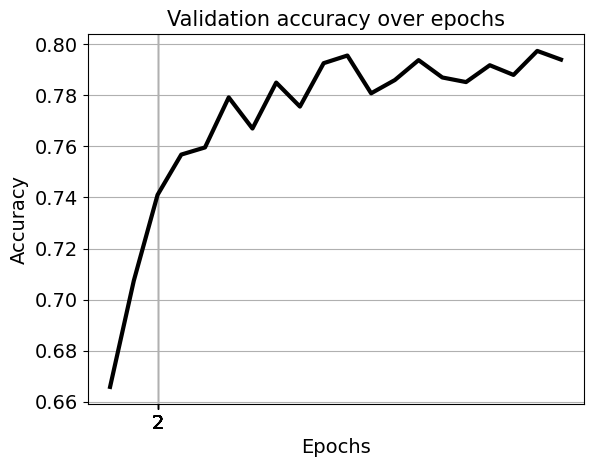

In [30]:
plt.title("Validation accuracy over epochs", fontsize=15)
plt.plot(model_1.history.history['val_accuracy'], lw = 3, c='k')
plt.grid(True)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks([2*1 for i in range(11)], fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Freeze feature layers and rebuild model

In [31]:
for i in feature_layers:
    i.trainable = False

In [32]:
model_2 = Sequential(feature_layers + classification_layers)

show the model summary and see the feature layers (Conv2D) have been rendered untrainable now

In [33]:
model_2.summary

<bound method Model.summary of <Sequential name=sequential_2, built=True>>

Now train the model and see how it takes less overall time and still gets equal or higher performance (validation accuracy)

In [34]:
#transfer: train dense layers for new classification task
train_model(model_2,
             (x_train_gte5, y_train_gte5), 
             (x_test_gte5, y_test_gte5), num_classes)

x_train shape: (25000, 32, 32, 3)
25000 train samples
5000 test samples
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.9375 - loss: 0.1691 - val_accuracy: 0.8614 - val_loss: 0.4722
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.9425 - loss: 0.1557 - val_accuracy: 0.8660 - val_loss: 0.4891
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.9440 - loss: 0.1515 - val_accuracy: 0.8626 - val_loss: 0.4925
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.9466 - loss: 0.1441 - val_accuracy: 0.8624 - val_loss: 0.4908
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.9500 - loss: 0.1371 - val_accuracy: 0.8614 - val_loss: 0.5054
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.9520 - loss: 0.1291 - val_accuracy: 0.8612 - val_loss: 0.5184
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9522 - loss: 0.1300 - val_accuracy: 0.8628 - val_loss: 0.5214
Epoch 8/20


plot the accuracy

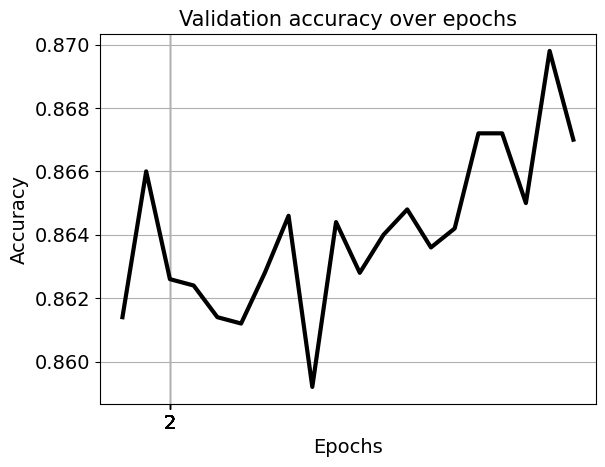

In [35]:
plt.title("Validation accuracy over epochs", fontsize=15)
plt.plot(model_2.history.history['val_accuracy'], lw = 3, c='k')
plt.grid(True)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks([2*1 for i in range(11)], fontsize=14)
plt.yticks(fontsize=14)
plt.show()

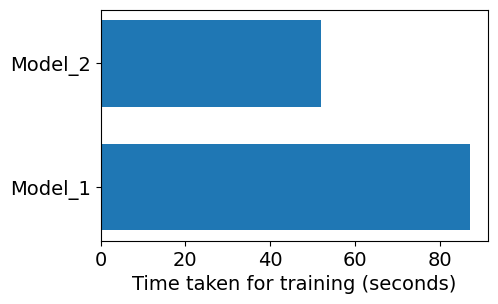

In [28]:
plt.figure(figsize=(5,3))
plt.barh(y=['Model_1', 'Model_2'], width=[87,52], height=0.7)
plt.xlabel("Time taken for training (seconds)", fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.show()